# Demo PFNRBicop with sampled data from Clayton copulas with x-dependent parameters

Goal: sample pairs $(U, V)$ from a Clayton copula where the parameter $\theta(x)$ depends on a covariate $x$.

Three scenarios:

- $\theta(x) = x, \quad x \in [2, 7]$
- $\theta(x) = 4$ with 0° rotation for $x \geq 0$, and $\theta(x) = 2$ with 90° rotation for $x < 0$, with $X \sim \mathcal{N}(0, 1)$
- $\theta(x) = 2$ no conditioning, but the model is trained with conditioning on $x$ as in Scenario 1

---

# Scenario 1

The copula parameter depends linearly on a covariate $x$.

$$
c(u, v \mid x) = c(u, v; \theta(x)),
$$

with $\theta(x) = x$ and $x \in [2, 7]$.

## Sampling strategy

For each observation index $i \in \{1, \dots, 2000\}$:
1. Set $x_i$ on a linear grid from 2 to 7.
2. Set copula parameter $\theta_i = x_i$.
3. Instantiate a Clayton pair copula with parameter $\theta_i$.
4. Draw one sample $(u_i, v_i)$ from that copula.

This gives a dataset $\{(x_i, u_i, v_i)\}_{i=1}^n$ where dependence changes with $x$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvinecopulib as pv

In [2]:
def sample_clayton_with_theta_x_identity(
    n: int = 2000,
    x_min: float = 2.0,
    x_max: float = 7.0,
    seed_base: int = 317,
) -> pd.DataFrame:
    x = np.linspace(x_min, x_max, n, dtype=np.float64)
    u = np.empty(n, dtype=np.float64)
    v = np.empty(n, dtype=np.float64)

    for i, theta in enumerate(x):
        bicop = pv.Bicop(
            family=pv.BicopFamily.clayton,
            parameters=np.asarray([[theta]], dtype=np.float64),
        )
        # Use deterministic per-row seeds so the whole dataset is reproducible.
        uv_i = bicop.simulate(n=1, seeds=[seed_base + i, seed_base + i + 1])
        u[i], v[i] = uv_i[0, 0], uv_i[0, 1]

    return pd.DataFrame({"x": x, "theta": x, "u": u, "v": v})

In [3]:
df = sample_clayton_with_theta_x_identity(n=2000)
df.head()

,x,theta,u,v
0,2.000000,2.000000,0.349132,0.291757
1,2.002501,2.002501,0.718970,0.486613
2,2.005003,2.005003,0.453947,0.347993
3,2.007504,2.007504,0.690153,0.611285
4,2.010005,2.010005,0.531634,0.319252


## Visual check

Color indicates $\theta=x$. Higher $x$ should show stronger lower-tail dependence for Clayton.

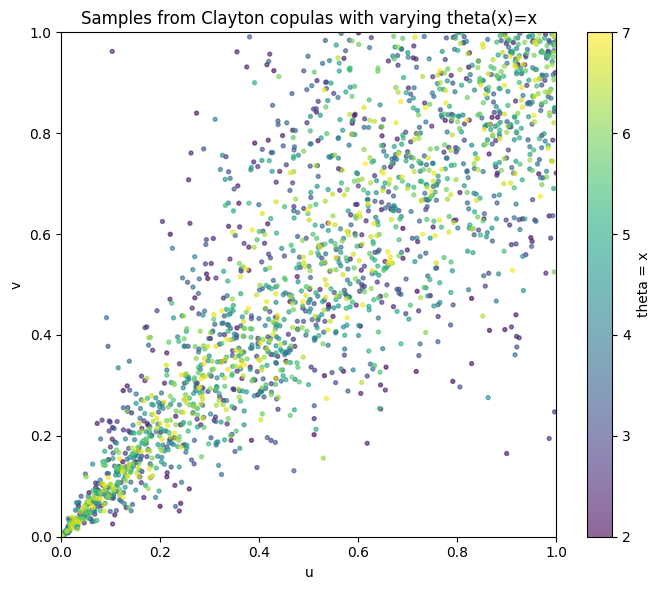

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df["u"], df["v"], c=df["theta"], s=8, alpha=0.6, cmap="viridis")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("theta = x")
ax.set_title("Samples from Clayton copulas with varying theta(x)=x")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Fit PFNRBicop to U, V given X

Now we fit a conditional copula model with `x` as covariate:
- `fit(u, v, x)` learns `c(u, v | x)`.
- We then evaluate fitted densities at observed pairs and on fixed `(u, v)` pairs while varying `x`.

In [5]:
from npcc import PFNRBicop

pfnr = PFNRBicop()
print("PFNRBicop device:", pfnr._device)

pfnr.fit(df["u"].to_numpy(), df["v"].to_numpy(), x=df[["x"]].to_numpy())

# Fitted conditional density at each observed (u_i, v_i | x_i)
c_hat = pfnr.pdf(df["u"].to_numpy(), df["v"].to_numpy(), x=df[["x"]].to_numpy())

df_fit = df.copy()
df_fit["c_hat"] = c_hat

df_fit[["x", "u", "v", "c_hat"]].head()

PFNRBicop device: cuda


C:\Users\flbuc\OneDrive\Documents\Research\npcc\src\npcc\_common.py:49: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  return torch.as_tensor(np.asarray(x), dtype=dtype, device=device)


,x,u,v,c_hat
0,2.000000,0.349132,0.291757,1.990734
1,2.002501,0.718970,0.486613,1.256603
2,2.005003,0.453947,0.347993,1.724840
3,2.007504,0.690153,0.611285,1.512625
4,2.010005,0.531634,0.319252,1.265373


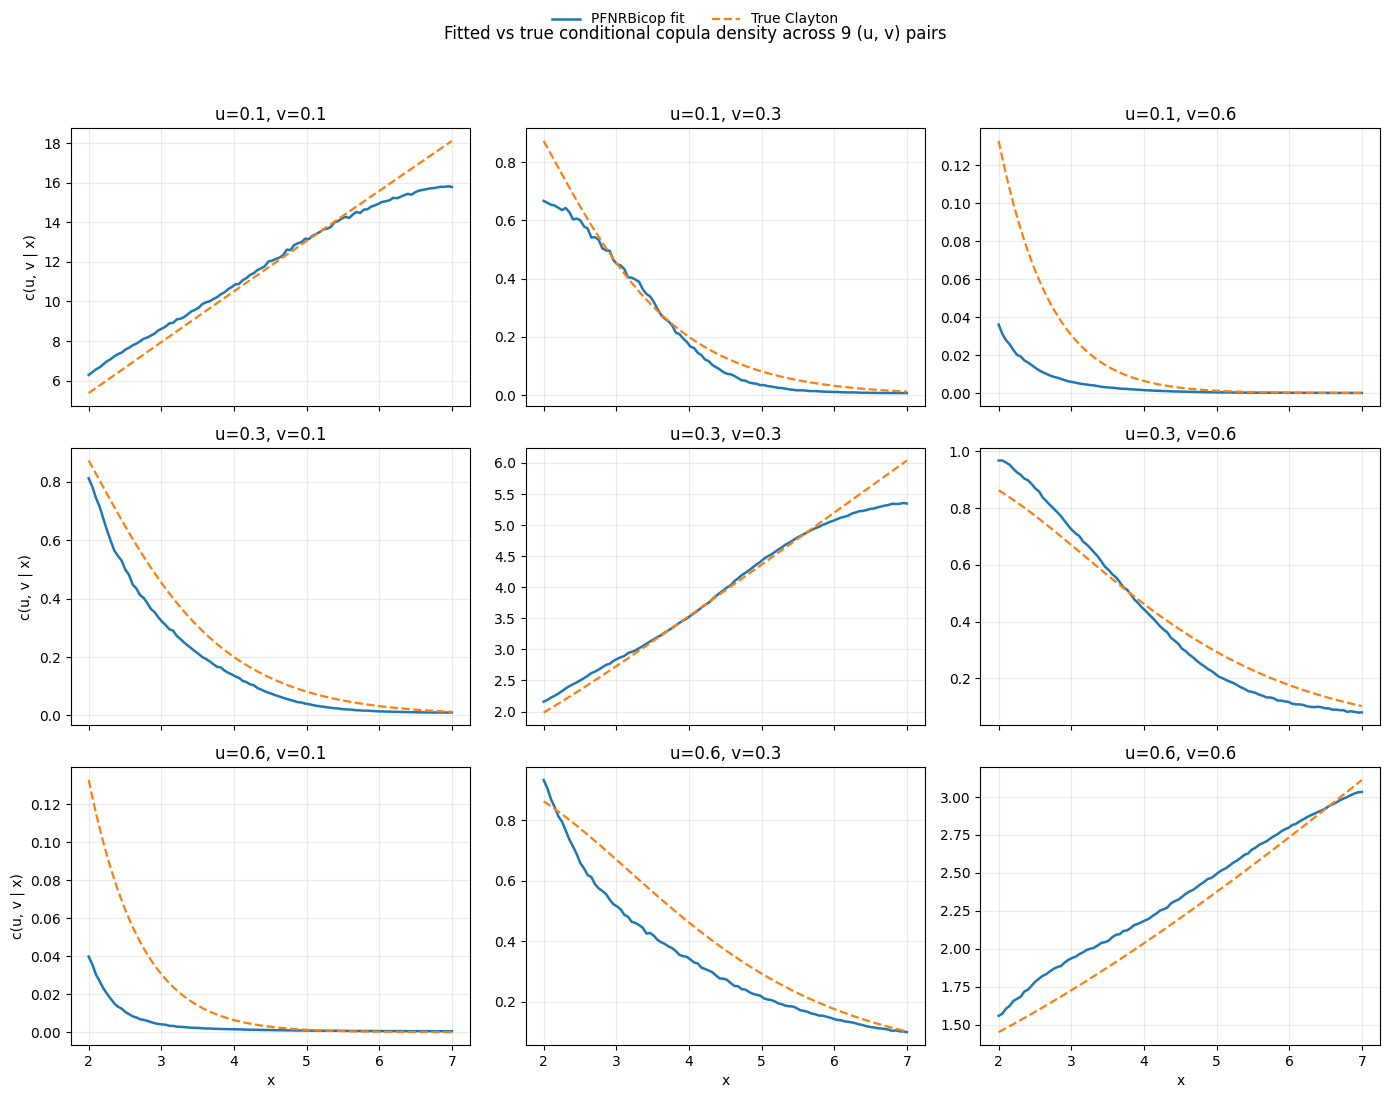

In [6]:
# Evaluate fitted and true c(u, v | x) for multiple fixed (u, v) pairs.
x_eval = np.linspace(2.0, 7.0, 100)
theta = x_eval

# 9 pairs for a 3x3 grid.
uv_pairs = [
    (0.1, 0.1), (0.1, 0.3), (0.1, 0.6),
    (0.3, 0.1), (0.3, 0.3), (0.3, 0.6),
    (0.6, 0.1), (0.6, 0.3), (0.6, 0.6),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    c_eval = pfnr.pdf(
        np.full_like(x_eval, u0, dtype=np.float64),
        np.full_like(x_eval, v0, dtype=np.float64),
        x=x_eval.reshape(-1, 1),
    )

    # True Clayton density with theta(x) = x:
    # c(u,v;theta) = (theta + 1) * (u*v)^(-theta-1) * (u^(-theta)+v^(-theta)-1)^(-2-1/theta)
    uv_term = (u0 * v0) ** (-theta - 1.0)
    sum_term = (u0 ** (-theta) + v0 ** (-theta) - 1.0) ** (-2.0 - 1.0 / theta)
    c_true = (theta + 1.0) * uv_term * sum_term

    ax.plot(x_eval, c_eval, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval, c_true, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("c(u, v | x)")

# One shared legend.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Fitted vs true conditional copula density across 9 (u, v) pairs", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Conditional distribution function: C(v, u | x)

Fitted vs true conditional distribution function across the same 9 (u, v) pairs.


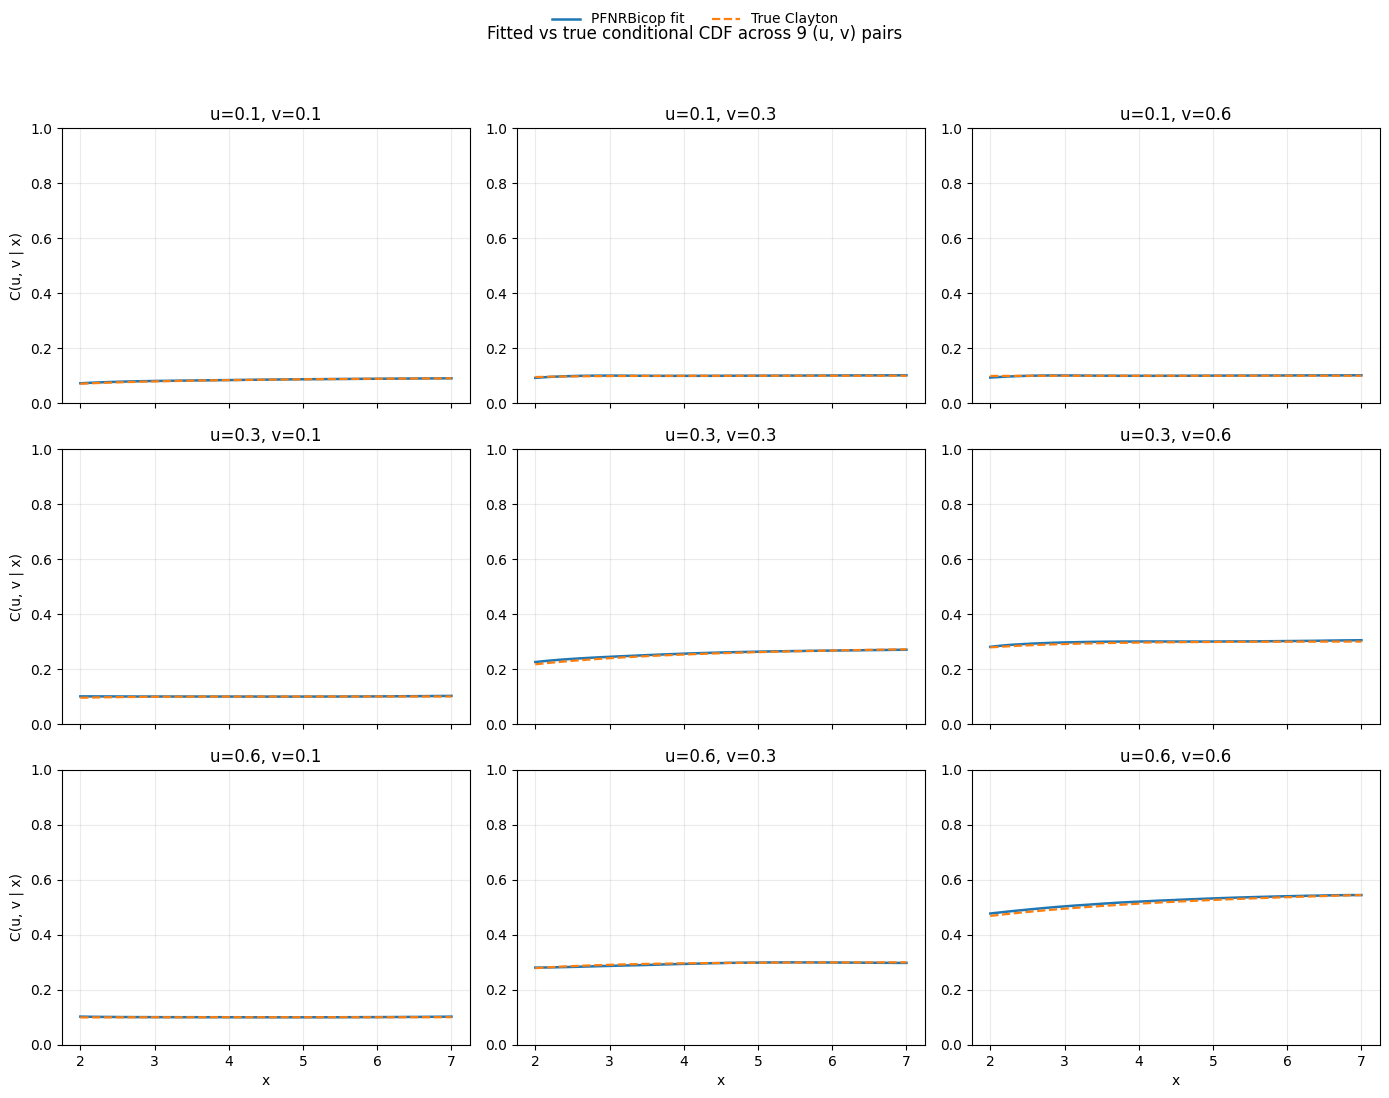

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    cdf_eval = pfnr.cdf(
        np.full_like(x_eval, u0, dtype=np.float64),
        np.full_like(x_eval, v0, dtype=np.float64),
        x=x_eval.reshape(-1, 1),
    )

    # True Clayton CDF: C(u,v;theta) = (u^(-theta) + v^(-theta) - 1)^(-1/theta)
    cdf_true = (u0 ** (-theta) + v0 ** (-theta) - 1.0) ** (-1.0 / theta)

    ax.plot(x_eval, cdf_eval, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval, cdf_true, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("C(u, v | x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Fitted vs true conditional CDF across 9 (u, v) pairs", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## H-function 1: h(v | u, x)

Conditional distribution of V given (U, X), fitted vs true across the 9 (u, v) pairs.


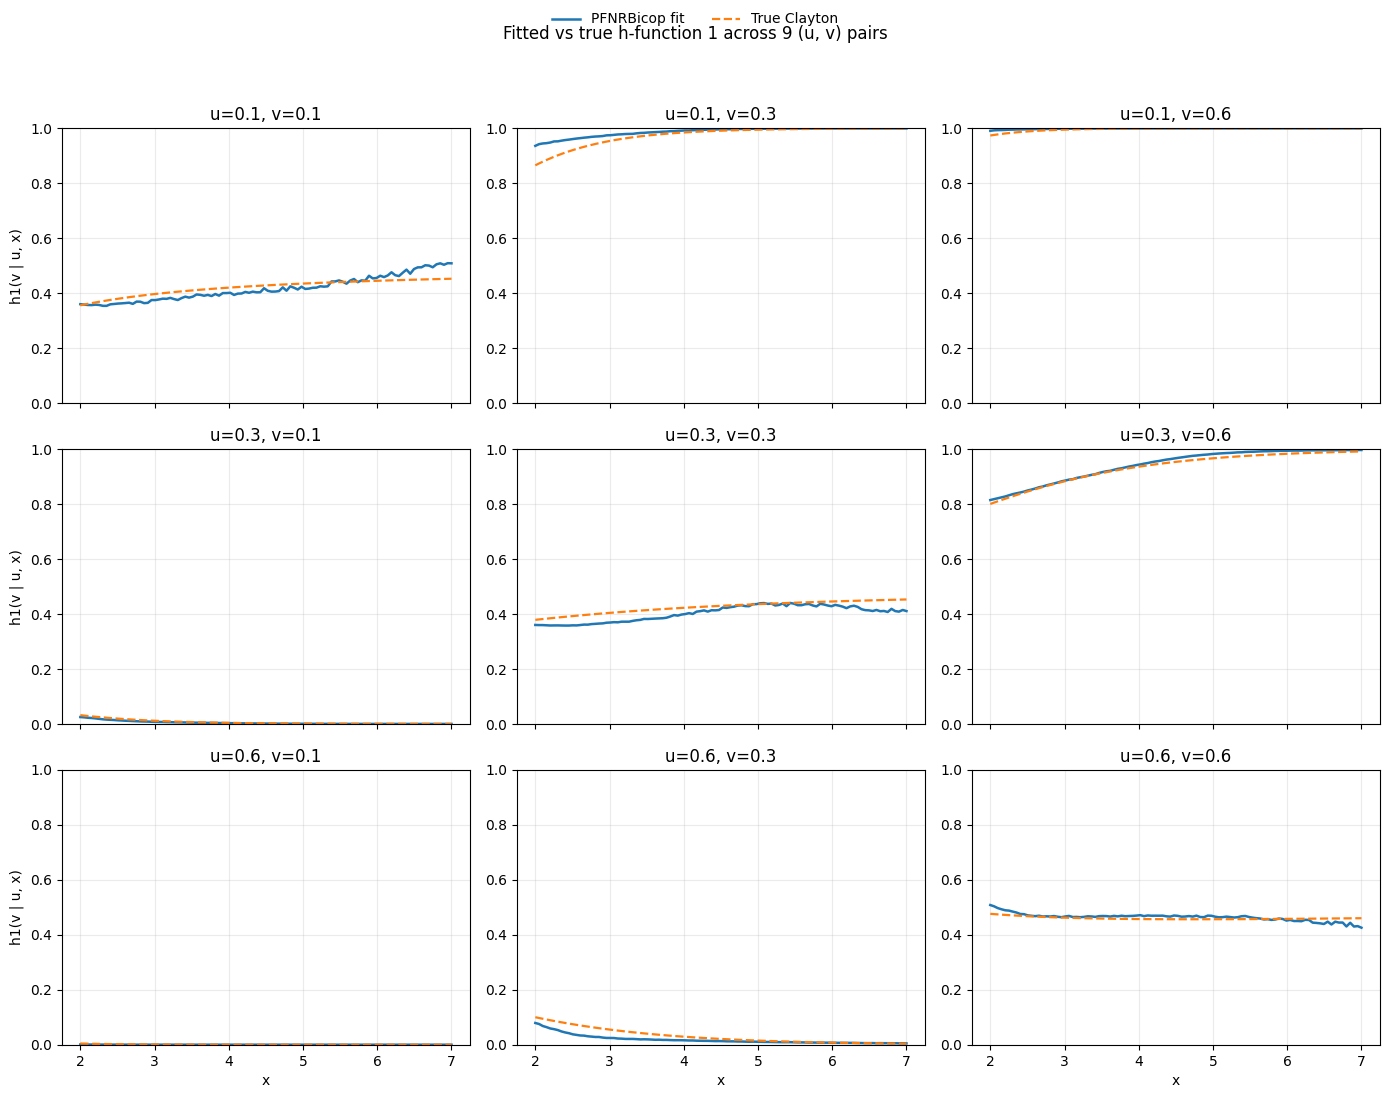

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    h1_eval = pfnr.hfunc1(
        np.full_like(x_eval, u0, dtype=np.float64),
        np.full_like(x_eval, v0, dtype=np.float64),
        x=x_eval.reshape(-1, 1),
    )

    # True Clayton h1: h(v|u;theta) = u^(-theta-1) * (u^(-theta) + v^(-theta) - 1)^(-1/theta - 1)
    h1_true = (u0 ** (-theta - 1.0)) * (u0 ** (-theta) + v0 ** (-theta) - 1.0) ** (-1.0 / theta - 1.0)

    ax.plot(x_eval, h1_eval, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval, h1_true, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("h1(v | u, x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Fitted vs true h-function 1 across 9 (u, v) pairs", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## H-function 2: h(u | v, x)

Conditional distribution of U given (V, X), fitted vs true across the 9 (u, v) pairs.


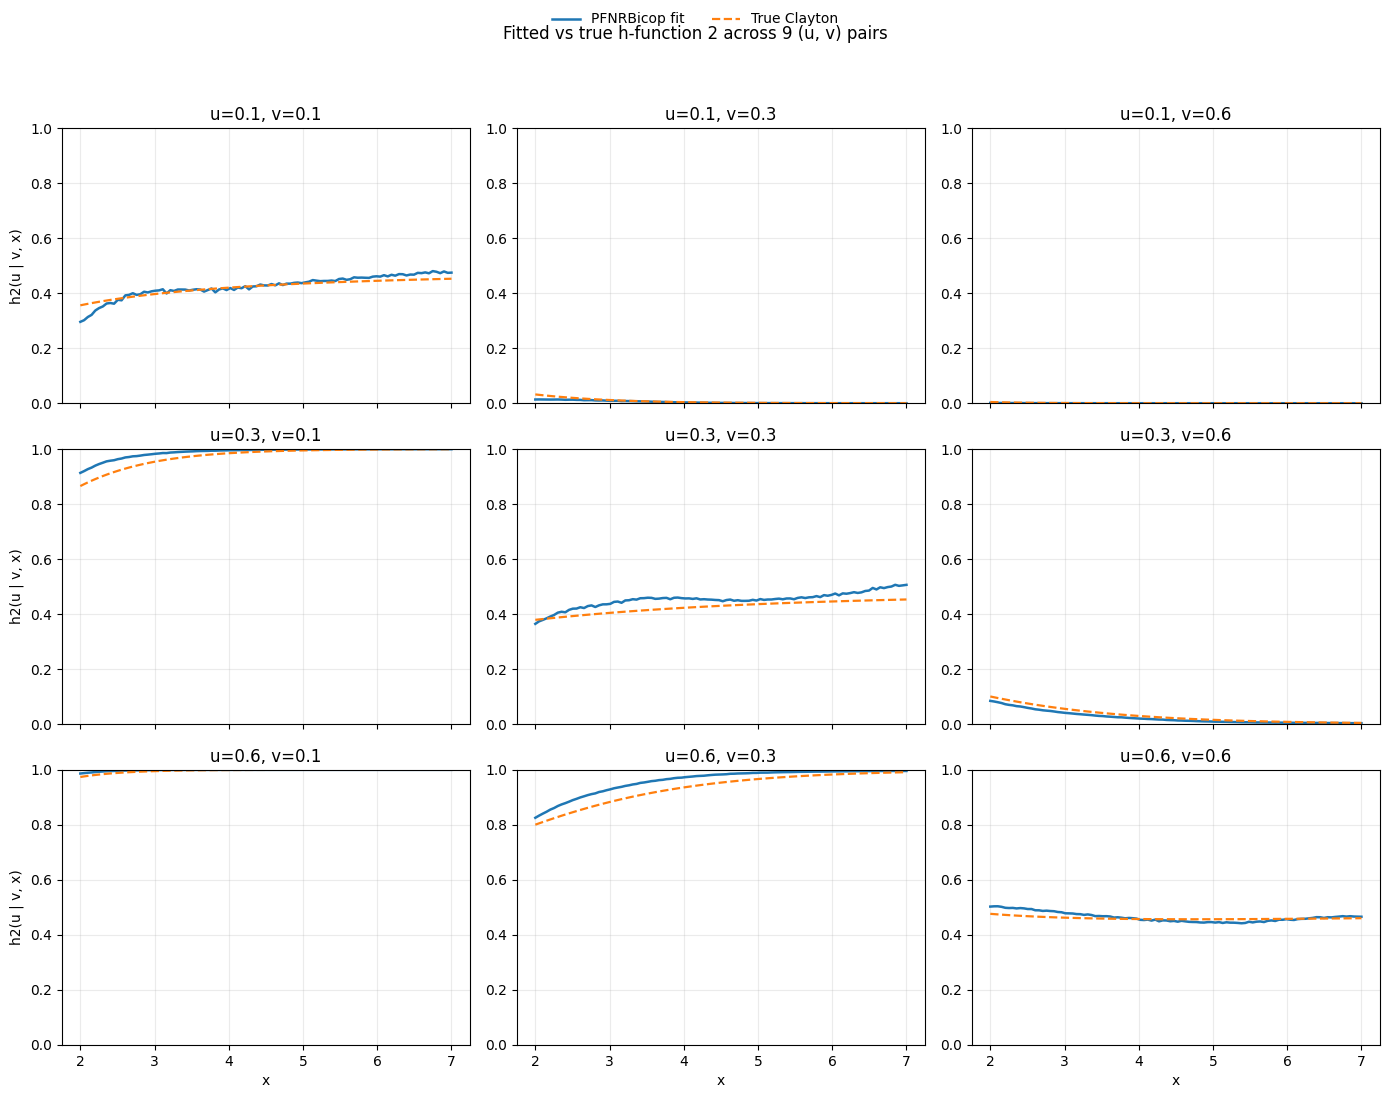

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    h2_eval = pfnr.hfunc2(
        np.full_like(x_eval, u0, dtype=np.float64),
        np.full_like(x_eval, v0, dtype=np.float64),
        x=x_eval.reshape(-1, 1),
    )

    # True Clayton h2: h(u|v;theta) = v^(-theta-1) * (u^(-theta) + v^(-theta) - 1)^(-1/theta - 1)
    h2_true = (v0 ** (-theta - 1.0)) * (u0 ** (-theta) + v0 ** (-theta) - 1.0) ** (-1.0 / theta - 1.0)

    ax.plot(x_eval, h2_eval, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval, h2_true, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("h2(u | v, x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Fitted vs true h-function 2 across 9 (u, v) pairs", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Kendall's $\tau$ comparison

We compare PFNRBicop's estimated conditional Kendall's $\tau$ to the Clayton truth
$\tau(x)=x/(x+2)$ at 8 values of $x$, and an empirical Kendall's $\tau$ for the binned data around the same $x$ values.

In [10]:
n_bins = 8
df_bins = df.copy()
df_bins["x_bin"] = pd.cut(df_bins["x"], bins=n_bins)

rows = []
for interval, g in df_bins.groupby("x_bin", observed=True):
    x_mid = 0.5 * (interval.left + interval.right)
    tau_emp = g["u"].corr(g["v"], method="kendall")
    tau_theory = x_mid / (x_mid + 2.0)
    rows.append((x_mid, tau_emp, tau_theory, len(g)))

tau_df = pd.DataFrame(rows, columns=["x_mid", "tau_emp", "tau_theory", "n"]).sort_values("x_mid")

x_tau = tau_df["x_mid"].to_numpy()

tau_pfnr = []
for x_val in x_tau:
    tau_pfnr.append(pfnr.tau(x_row=np.array([[x_val]], dtype=np.float64), n=1000))

tau_pfnr = np.asarray(tau_pfnr, dtype=np.float64)
tau_true = x_tau / (x_tau + 2.0)

tau_cmp = pd.DataFrame(
    {
        "x": x_tau,
        "tau_pfnr": tau_pfnr,
        "tau_true": tau_true,
        "abs_err": np.abs(tau_pfnr - tau_true),
    }
)

display(tau_cmp)

,x,tau_pfnr,tau_true,abs_err
0,2.3100,0.543800,0.535963,0.007837
1,2.9375,0.611435,0.594937,0.016499
2,3.5625,0.655964,0.640449,0.015515
3,4.1875,0.691387,0.676768,0.014620
4,4.8125,0.721297,0.706422,0.014875
5,5.4375,0.743884,0.731092,0.012791
6,6.0625,0.760136,0.751938,0.008198
7,6.6875,0.771347,0.769784,0.001563


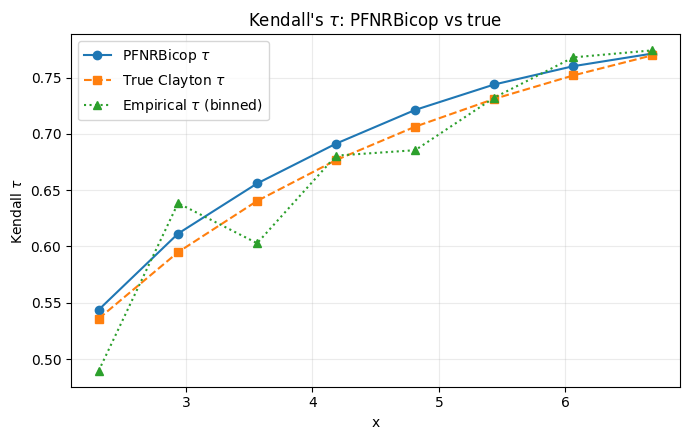

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_tau, tau_pfnr, marker="o", label="PFNRBicop $\\tau$")
ax.plot(x_tau, tau_true, marker="s", linestyle="--", label="True Clayton $\\tau$")
ax.plot(tau_df["x_mid"], tau_df["tau_emp"], marker="^", linestyle=":", label="Empirical $\\tau$ (binned)")
ax.set_xlabel("x")
ax.set_ylabel("Kendall $\\tau$")
ax.set_title("Kendall's $\\tau$: PFNRBicop vs true")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

---

# Scenario 2


## Sampling strategy

For $i \in \{1, \dots, 2000\}$
1. Sample $x_i \sim \mathcal{N}(0, 1)$
2. - If $x_i < 0$: sample $(u_i, v_i)$ from Clayton with $\theta = 2$ and 90° rotation
   - If $x_i \geq 0$: sample $(u_i, v_i)$ from Clayton with $\theta = 4$ and 0° rotation

This gives a dataset $\{(x_i, u_i, v_i)\}_{i=1}^n$ where $x$ is continuous, but dependence changes only at a certain threshold.


In [12]:
def sample_piecewise_clayton(
    n: int = 2000,
    seed_base: int = 317,
) -> pd.DataFrame:
    """
    Sample from piecewise Clayton copula.
    x ~ N(0,1)
    if x < 0: Clayton(theta=2, rotation=90)
    if x >= 0: Clayton(theta=4, rotation=0)
    """
    np.random.seed(seed_base)
    x = np.random.standard_normal(n)
    u = np.empty(n, dtype=np.float64)
    v = np.empty(n, dtype=np.float64)
    theta_vals = np.empty(n, dtype=np.float64)

    for i, x_val in enumerate(x):
        if x_val < 0:
            theta = 2.0
            rotation = 90
        else:
            theta = 4.0
            rotation = 0
        
        theta_vals[i] = theta
        
        bicop = pv.Bicop(
            family=pv.BicopFamily.clayton,
            parameters=np.asarray([[theta]], dtype=np.float64),
            rotation=rotation,
        )
        uv_i = bicop.simulate(n=1, seeds=[seed_base + i, seed_base + i + 1])
        u[i], v[i] = uv_i[0, 0], uv_i[0, 1]

    return pd.DataFrame({"x": x, "theta": theta_vals, "u": u, "v": v})

df2 = sample_piecewise_clayton(n=2000)
df2.head()

,x,theta,u,v
0,1.084339,4.0,0.349132,0.303721
1,-0.937466,2.0,0.718970,0.212650
2,0.081502,4.0,0.453947,0.379810
3,0.492217,4.0,0.690153,0.652603
4,0.594602,4.0,0.531634,0.386627


## Visual check

Color indicates $\theta$: darker (2) for $x < 0$, lighter (4) for $x \geq 0$.


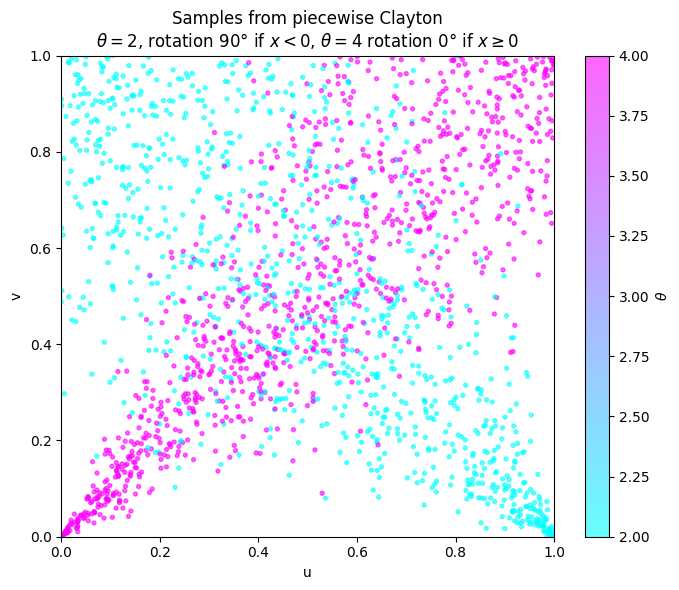

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df2["u"], df2["v"], c=df2["theta"], s=8, alpha=0.6, cmap="cool")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("$\\theta$")
ax.set_title(
    "Samples from piecewise Clayton\n"
    r"$\theta=2$, rotation 90° if $x<0$, $\theta=4$ rotation 0° if $x\geq0$"
    )
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Fit PFNRBicop to Scenario 2 data

Fit conditional copula model with x as covariate.


In [14]:
pfnr2 = PFNRBicop()
pfnr2.fit(df2["u"].to_numpy(), df2["v"].to_numpy(), x=df2[["x"]].to_numpy())

c_hat2 = pfnr2.pdf(df2["u"].to_numpy(), df2["v"].to_numpy(), x=df2[["x"]].to_numpy())
df2_fit = df2.copy()
df2_fit["c_hat"] = c_hat2

print("Scenario 2 PFNRBicop fit complete")

Scenario 2 PFNRBicop fit complete


## Conditional density comparison (3x3 Grid)


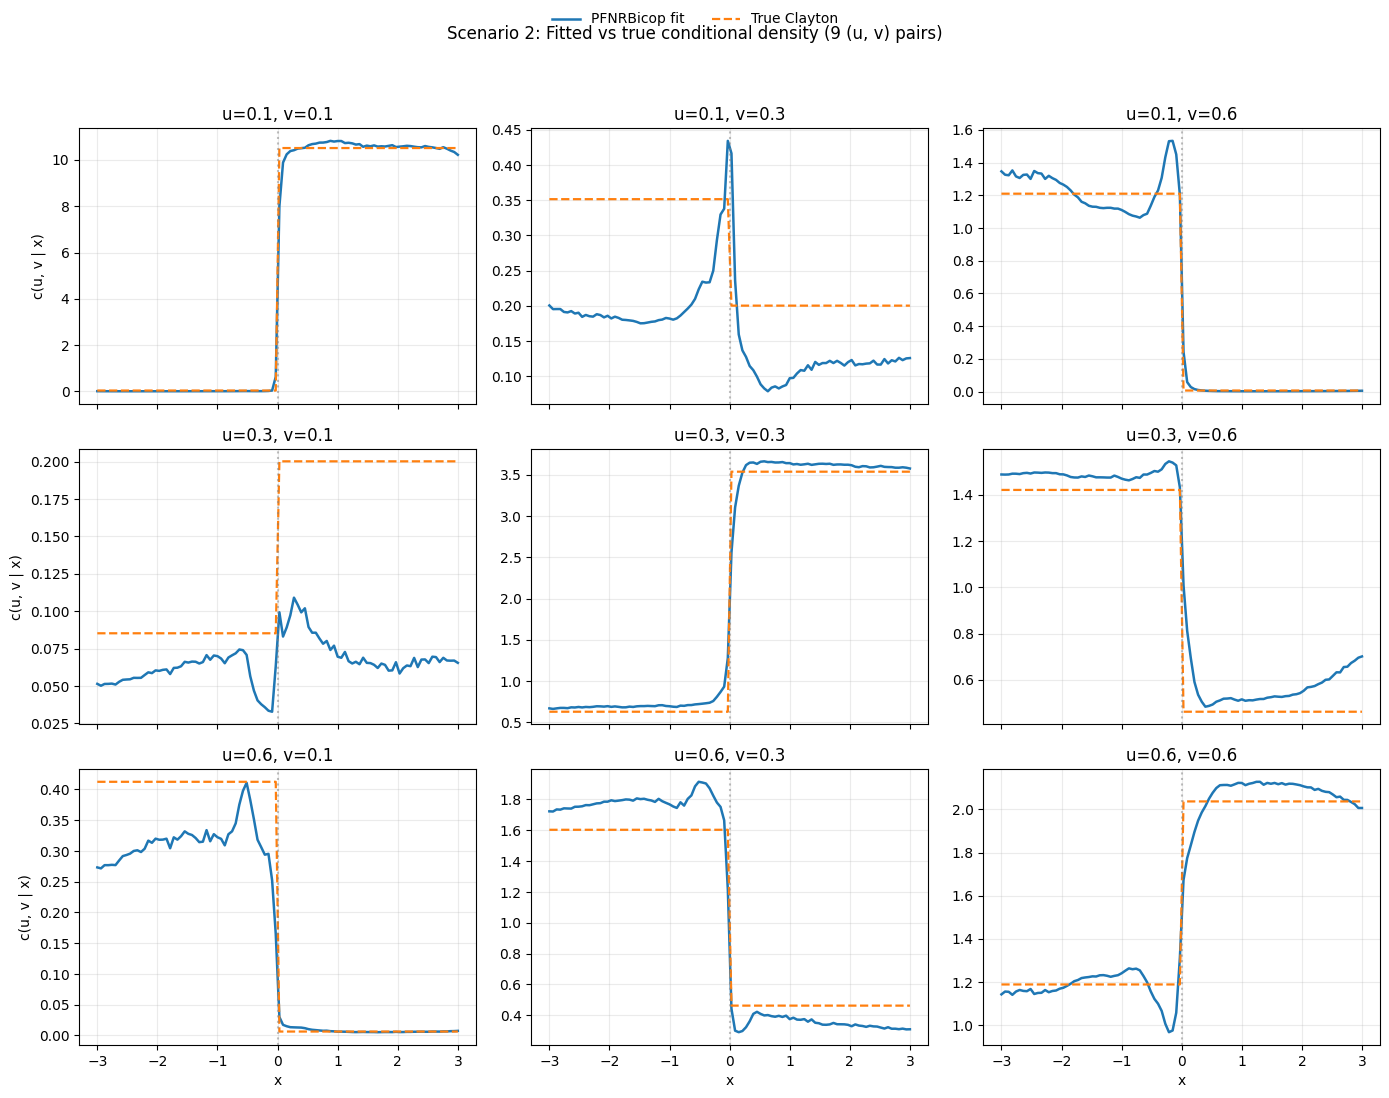

In [15]:
x_eval2 = np.linspace(-3.0, 3.0, 100)

fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    c_eval2 = pfnr2.pdf(
        np.full_like(x_eval2, u0, dtype=np.float64),
        np.full_like(x_eval2, v0, dtype=np.float64),
        x=x_eval2.reshape(-1, 1),
    )

    # True Clayton density: depends on x and rotation
    theta_eval = np.where(x_eval2 < 0, 2.0, 4.0)
    
    # For x < 0: 90° rotation transforms (u, v) -> (1-u, v)
    # For x >= 0: standard Clayton, no rotation
    u_eval = np.where(x_eval2 < 0, 1.0 - u0, u0)
    v_eval = v0
    
    uv_term = (u_eval * v_eval) ** (-theta_eval - 1.0)
    sum_term = (u_eval ** (-theta_eval) + v_eval ** (-theta_eval) - 1.0) ** (-2.0 - 1.0 / theta_eval)
    c_true2 = (theta_eval + 1.0) * uv_term * sum_term

    ax.plot(x_eval2, c_eval2, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval2, c_true2, "--", label="True Clayton", linewidth=1.6)
    ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("c(u, v | x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 2: Fitted vs true conditional density (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Conditional distribution function comparison (3x3 Grid)


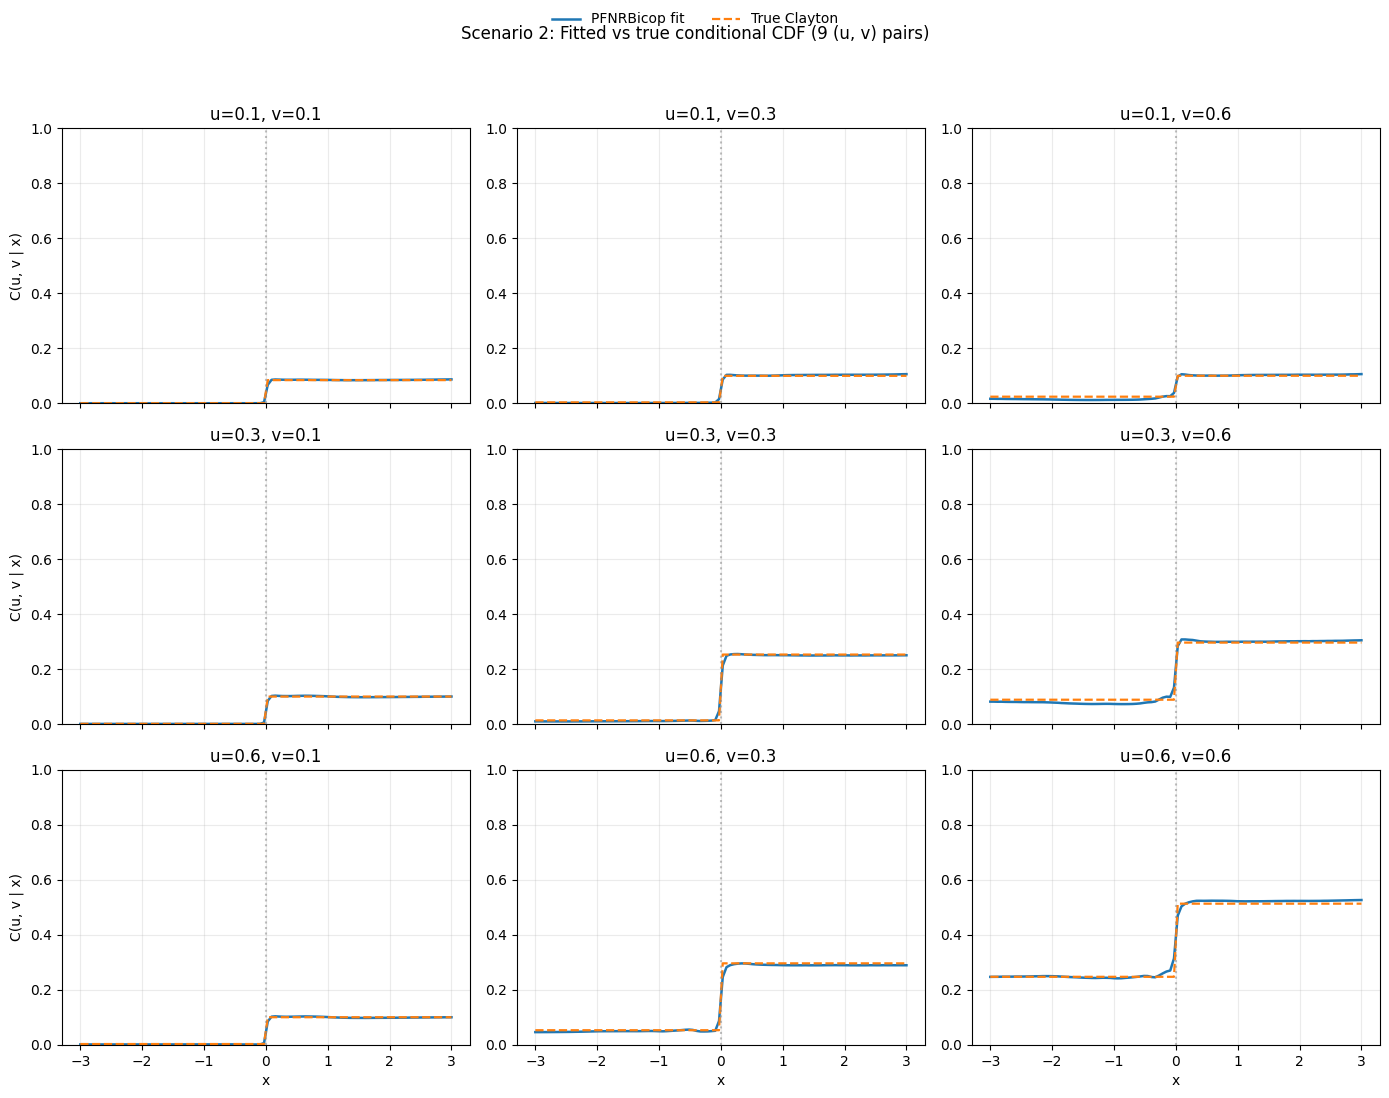

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    cdf_eval2 = pfnr2.cdf(
        np.full_like(x_eval2, u0, dtype=np.float64),
        np.full_like(x_eval2, v0, dtype=np.float64),
        x=x_eval2.reshape(-1, 1),
    )

    # True Clayton CDF with rotation accounting
    theta_eval = np.where(x_eval2 < 0, 2.0, 4.0)
    
    # Standard Clayton CDF: C(u,v;theta) = (u^(-theta) + v^(-theta) - 1)^(-1/theta)
    # For x < 0 (90° rotation): C_90(u,v) = v - C(1-u, v)
    u_std = np.where(x_eval2 < 0, 1.0 - u0, u0)
    v_std = v0
    
    c_std = (u_std ** (-theta_eval) + v_std ** (-theta_eval) - 1.0) ** (-1.0 / theta_eval)
    # Apply rotation transformation if needed
    cdf_true2 = np.where(x_eval2 < 0, v_std - c_std, c_std)

    ax.plot(x_eval2, cdf_eval2, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval2, cdf_true2, "--", label="True Clayton", linewidth=1.6)
    ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("C(u, v | x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 2: Fitted vs true conditional CDF (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## H-function 1 comparison (3x3 Grid)


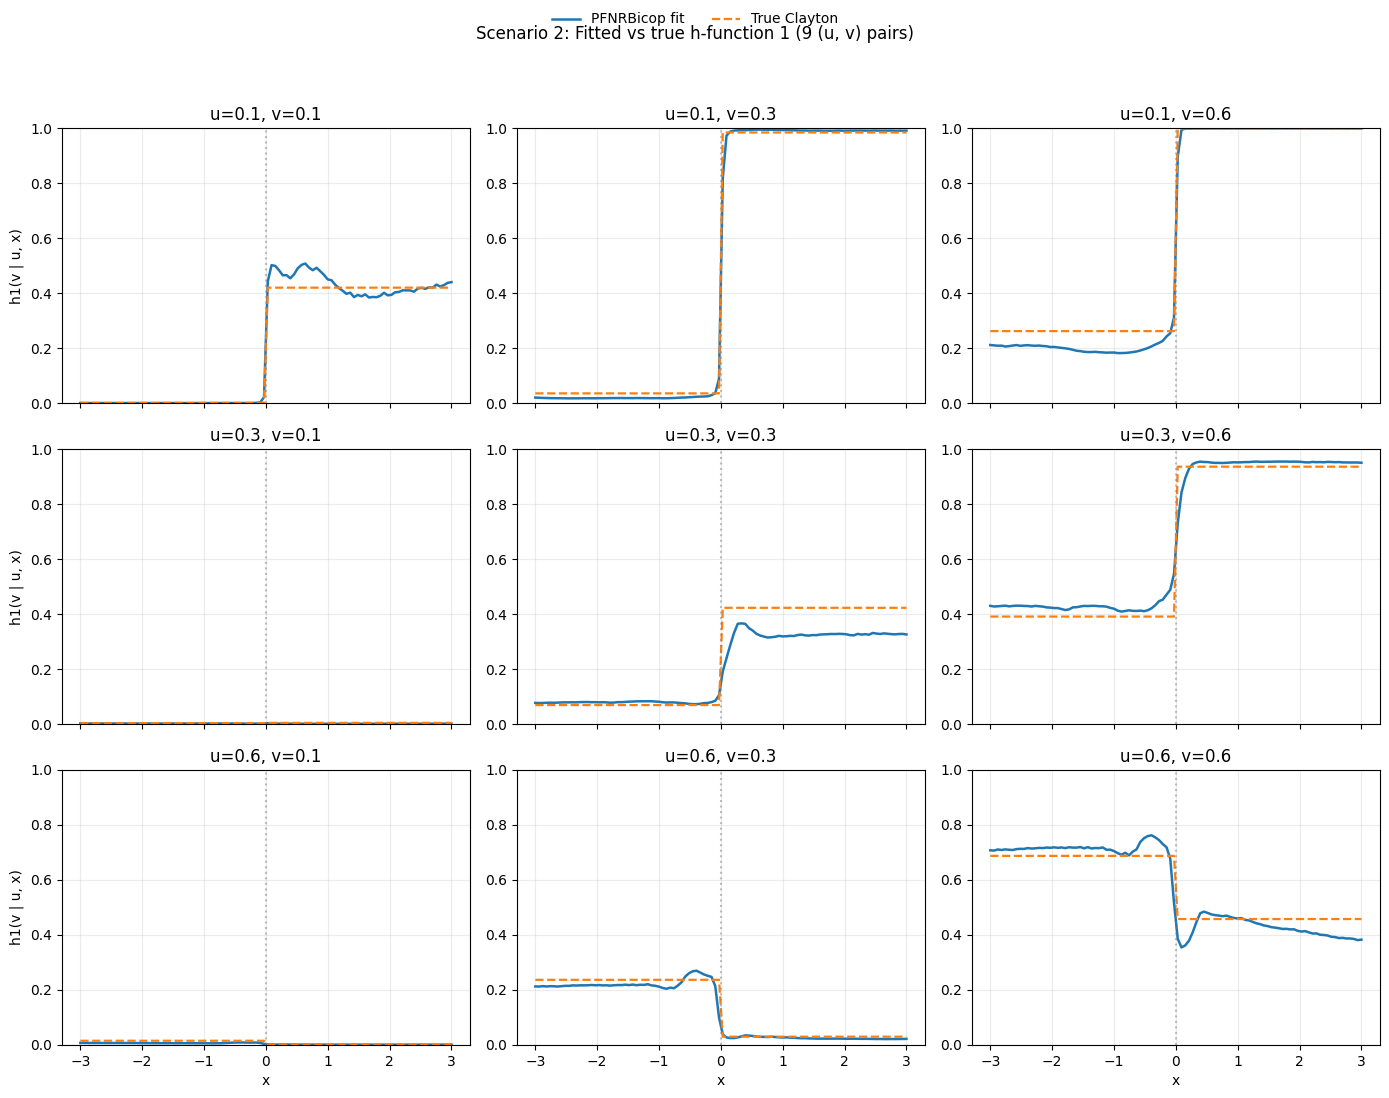

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    h1_eval2 = pfnr2.hfunc1(
        np.full_like(x_eval2, u0, dtype=np.float64),
        np.full_like(x_eval2, v0, dtype=np.float64),
        x=x_eval2.reshape(-1, 1),
    )

    # True Clayton h1 with rotation accounting
    theta_eval = np.where(x_eval2 < 0, 2.0, 4.0)
    
    # For x < 0: 90° rotation transforms (u, v) -> (1-u, v)
    u_eval = np.where(x_eval2 < 0, 1.0 - u0, u0)
    v_eval = v0
    
    h1_true2 = (u_eval ** (-theta_eval - 1.0)) * (u_eval ** (-theta_eval) + v_eval ** (-theta_eval) - 1.0) ** (-1.0 / theta_eval - 1.0)

    ax.plot(x_eval2, h1_eval2, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval2, h1_true2, "--", label="True Clayton", linewidth=1.6)
    ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("h1(v | u, x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 2: Fitted vs true h-function 1 (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## H-function 2 comparison (3x3 Grid)


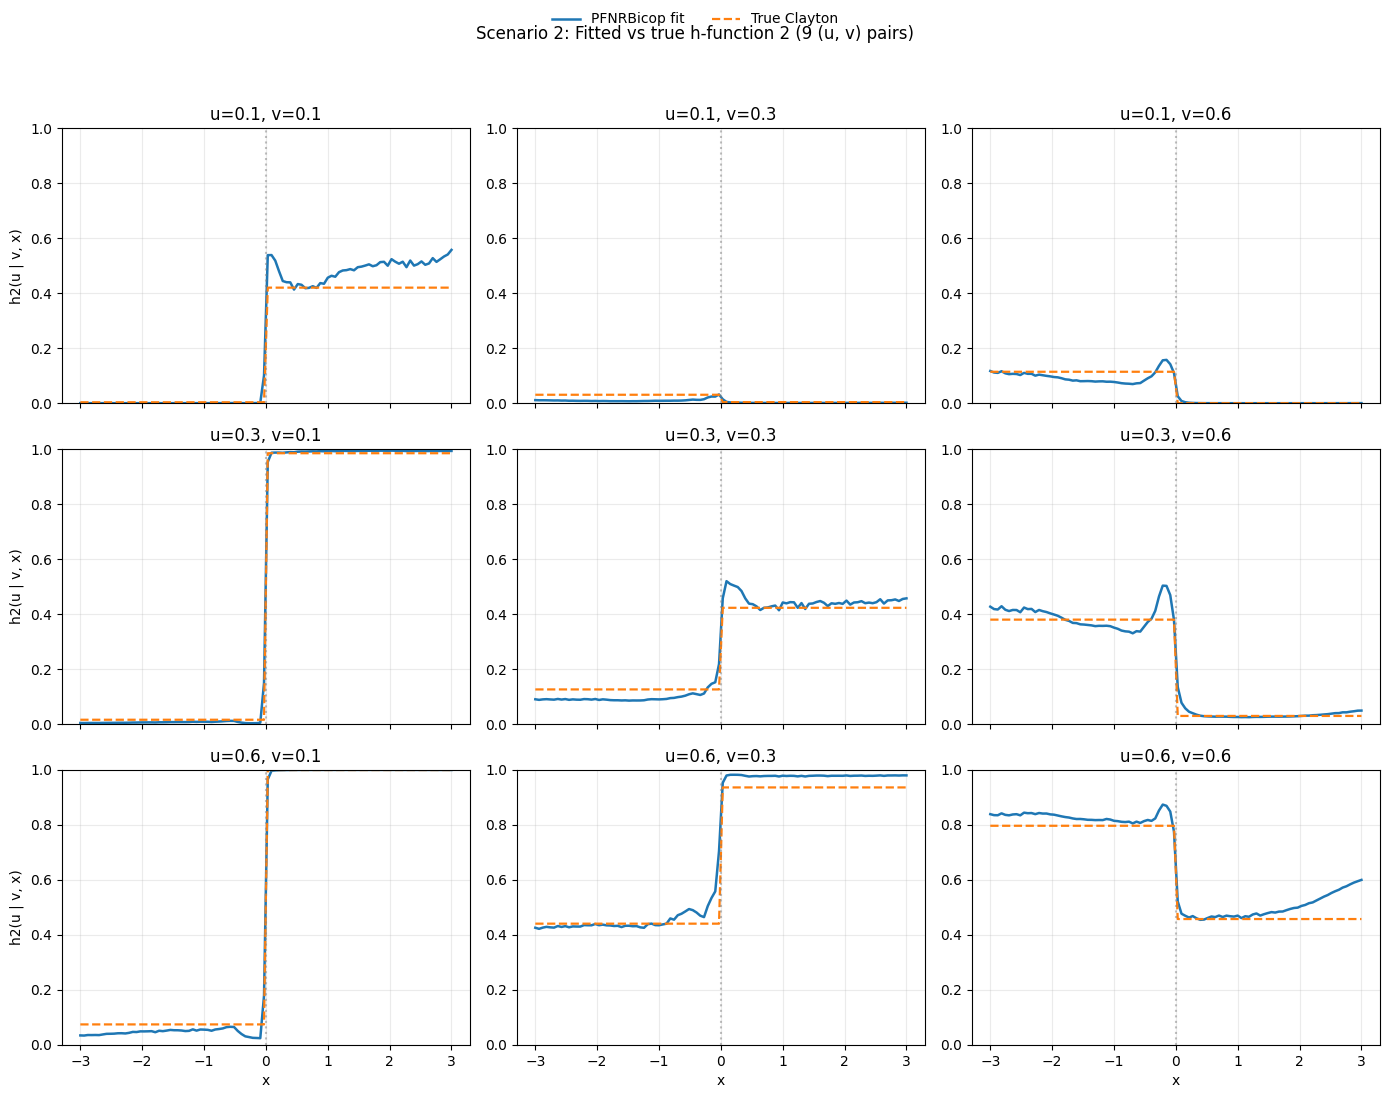

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    h2_eval2 = pfnr2.hfunc2(
        np.full_like(x_eval2, u0, dtype=np.float64),
        np.full_like(x_eval2, v0, dtype=np.float64),
        x=x_eval2.reshape(-1, 1),
    )

    # True Clayton h2 with rotation accounting
    theta_eval = np.where(x_eval2 < 0, 2.0, 4.0)
    
    # For x < 0: 90° rotation gives h2_90(u,v) = 1 - h2(1-u, v; theta)
    # For x >= 0: standard h2(u,v; theta)
    u_eval = np.where(x_eval2 < 0, 1.0 - u0, u0)
    v_eval = v0
    
    h2_base = (v_eval ** (-theta_eval - 1.0)) * (u_eval ** (-theta_eval) + v_eval ** (-theta_eval) - 1.0) ** (-1.0 / theta_eval - 1.0)
    h2_true2 = np.where(x_eval2 < 0, 1.0 - h2_base, h2_base)

    ax.plot(x_eval2, h2_eval2, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval2, h2_true2, "--", label="True Clayton", linewidth=1.6)
    ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("h2(u | v, x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 2: Fitted vs true h-function 2 (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Kendall's $\tau$ comparison (Binned x Values)

Compare PFNRBicop's estimated $\tau$ to true $\tau$ at the binned x midpoints.


In [19]:
n_bins = 8
df2_bins = df2.copy()
df2_bins["x_bin"] = pd.cut(df2_bins["x"], bins=n_bins)

rows = []
for interval, g in df2_bins.groupby("x_bin", observed=True):
    x_mid = 0.5 * (interval.left + interval.right)
    tau_emp = g["u"].corr(g["v"], method="kendall")
    true_theta = 2.0 if x_mid < 0 else 4.0
    tau_theory = -(true_theta / (true_theta + 2.0)) if x_mid < 0 else (true_theta / (true_theta + 2.0))
    rows.append((x_mid, tau_emp, tau_theory, true_theta, len(g)))

tau_df2 = pd.DataFrame(
    rows, columns=["x_mid", "tau_emp", "tau_theory", "true_theta", "n"]
).sort_values("x_mid")

x_tau2 = tau_df2["x_mid"].to_numpy()

tau_pfnr2 = []
for x_val in x_tau2:
    tau_pfnr2.append(pfnr2.tau(x_row=np.array([[x_val]], dtype=np.float64), n=1000))

tau_pfnr2 = np.asarray(tau_pfnr2, dtype=np.float64)
tau_true2 = tau_df2["tau_theory"].to_numpy()

tau_cmp2 = pd.DataFrame(
    {
        "x": x_tau2,
        "tau_pfnr": tau_pfnr2,
        "tau_true": tau_true2,
        "tau_emp": tau_df2["tau_emp"].to_numpy(),
        "abs_err": np.abs(tau_pfnr2 - tau_true2),
    }
)

display(tau_cmp2)

,x,tau_pfnr,tau_true,tau_emp,abs_err
0,-3.1220,-0.538783,-0.500000,-0.484848,0.038783
1,-2.1860,-0.548368,-0.500000,-0.545570,0.048368
2,-1.2535,-0.546086,-0.500000,-0.536581,0.046086
3,-0.3210,-0.535335,-0.500000,-0.297911,0.035335
4,0.6115,0.682446,0.666667,0.668199,0.015780
5,1.5440,0.674082,0.666667,0.653544,0.007415
6,2.4765,0.671499,0.666667,0.632576,0.004833
7,3.4090,0.659724,0.666667,-0.333333,0.006943


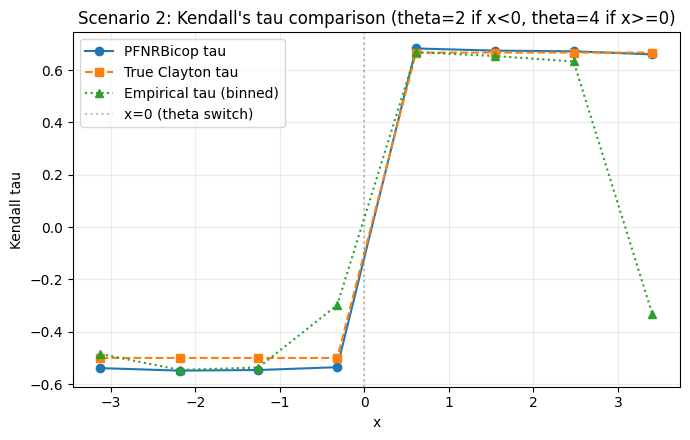

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_tau2, tau_pfnr2, marker="o", label="PFNRBicop tau")
ax.plot(x_tau2, tau_true2, marker="s", linestyle="--", label="True Clayton tau")
ax.plot(x_tau2, tau_df2["tau_emp"].to_numpy(), marker="^", linestyle=":", label="Empirical tau (binned)")
ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5, label="x=0 (theta switch)")
ax.set_xlabel("x")
ax.set_ylabel("Kendall tau")
ax.set_title("Scenario 2: Kendall's tau comparison (theta=2 if x<0, theta=4 if x>=0)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

---

# Scenario 3

Constant Clayton copula with $\theta = 2$ and 0° rotation, but fit with conditioning on the Scenario 1 covariate $x$.

This is a negative-control scenario: the true copula does not depend on $x$, so the fitted conditional copula should remain approximately constant across $x$.

## Sampling strategy

For each observation index $i \in \{1, \dots, 2000\}$:
1. Reuse the Scenario 1 covariate value $x_i \in [2, 7]$.
2. Sample $(u_i, v_i)$ from a Clayton copula with $\theta = 2$ and 0° rotation.
3. Fit the conditional copula model using $x_i$ as covariate, even though the true copula does not depend on $x_i$.

This gives a dataset $\{(x_i, u_i, v_i)\}_{i=1}^n$ where the conditioning variable is observed but irrelevant.

In [30]:
def sample_constant_clayton_with_scenario1_x(
    theta: float = 2.0,
    n: int = 2000,
    seed_base: int = 731,
) -> pd.DataFrame:
    x = df["x"].to_numpy()[:n].copy()
    u = np.empty(n, dtype=np.float64)
    v = np.empty(n, dtype=np.float64)

    bicop = pv.Bicop(
        family=pv.BicopFamily.clayton,
        parameters=np.asarray([[theta]], dtype=np.float64),
        rotation=0,
    )

    for i in range(n):
        uv_i = bicop.simulate(n=1, seeds=[seed_base + i, seed_base + i + 1])
        u[i], v[i] = uv_i[0, 0], uv_i[0, 1]

    return pd.DataFrame({"x": x, "theta": theta, "u": u, "v": v})


df3 = sample_constant_clayton_with_scenario1_x(n=2000)
df3.head()

,x,theta,u,v
0,2.000000,2.0,0.283451,0.314416
1,2.002501,2.0,0.248939,0.345862
2,2.005003,2.0,0.899568,0.697411
3,2.007504,2.0,0.062014,0.023708
4,2.010005,2.0,0.722354,0.282419


## Visual check

Color indicates the Scenario 1 covariate $x$. Since the true copula is constant in $x$, the scatter should not show a systematic dependence change across colors.

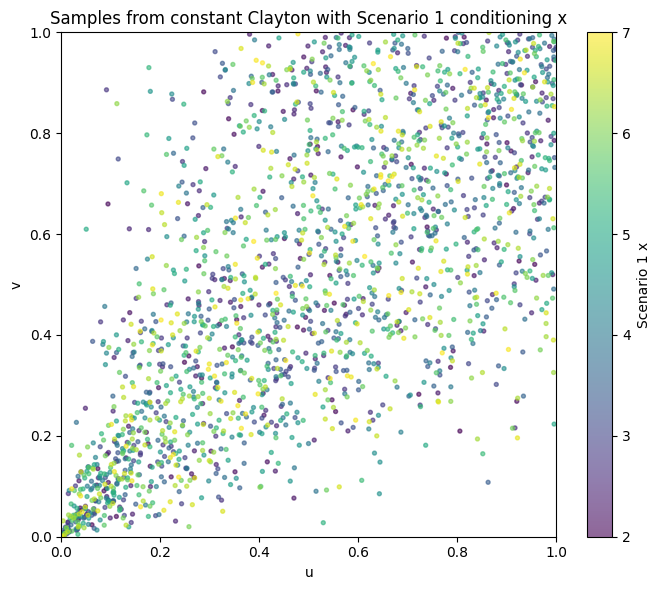

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df3["u"], df3["v"], c=df3["x"], s=8, alpha=0.6, cmap="viridis")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Scenario 1 x")
ax.set_title("Samples from constant Clayton with Scenario 1 conditioning x")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Fit PFNRBicop to Scenario 3 data

Fit the conditional copula model using the Scenario 1 covariate $x$, even though the true copula is constant in $x$.

In [32]:
pfnr3 = PFNRBicop()
pfnr3.fit(df3["u"].to_numpy(), df3["v"].to_numpy(), x=df3[["x"]].to_numpy())

c_hat3 = pfnr3.pdf(df3["u"].to_numpy(), df3["v"].to_numpy(), x=df3[["x"]].to_numpy())
df3_fit = df3.copy()
df3_fit["c_hat"] = c_hat3

df3_fit[["x", "u", "v", "c_hat"]].head()

,x,u,v,c_hat
0,2.000000,0.283451,0.314416,1.921259
1,2.002501,0.248939,0.345862,1.804329
2,2.005003,0.899568,0.697411,1.562632
3,2.007504,0.062014,0.023708,5.822198
4,2.010005,0.722354,0.282419,0.495342


## Conditional density comparison (3x3 grid)

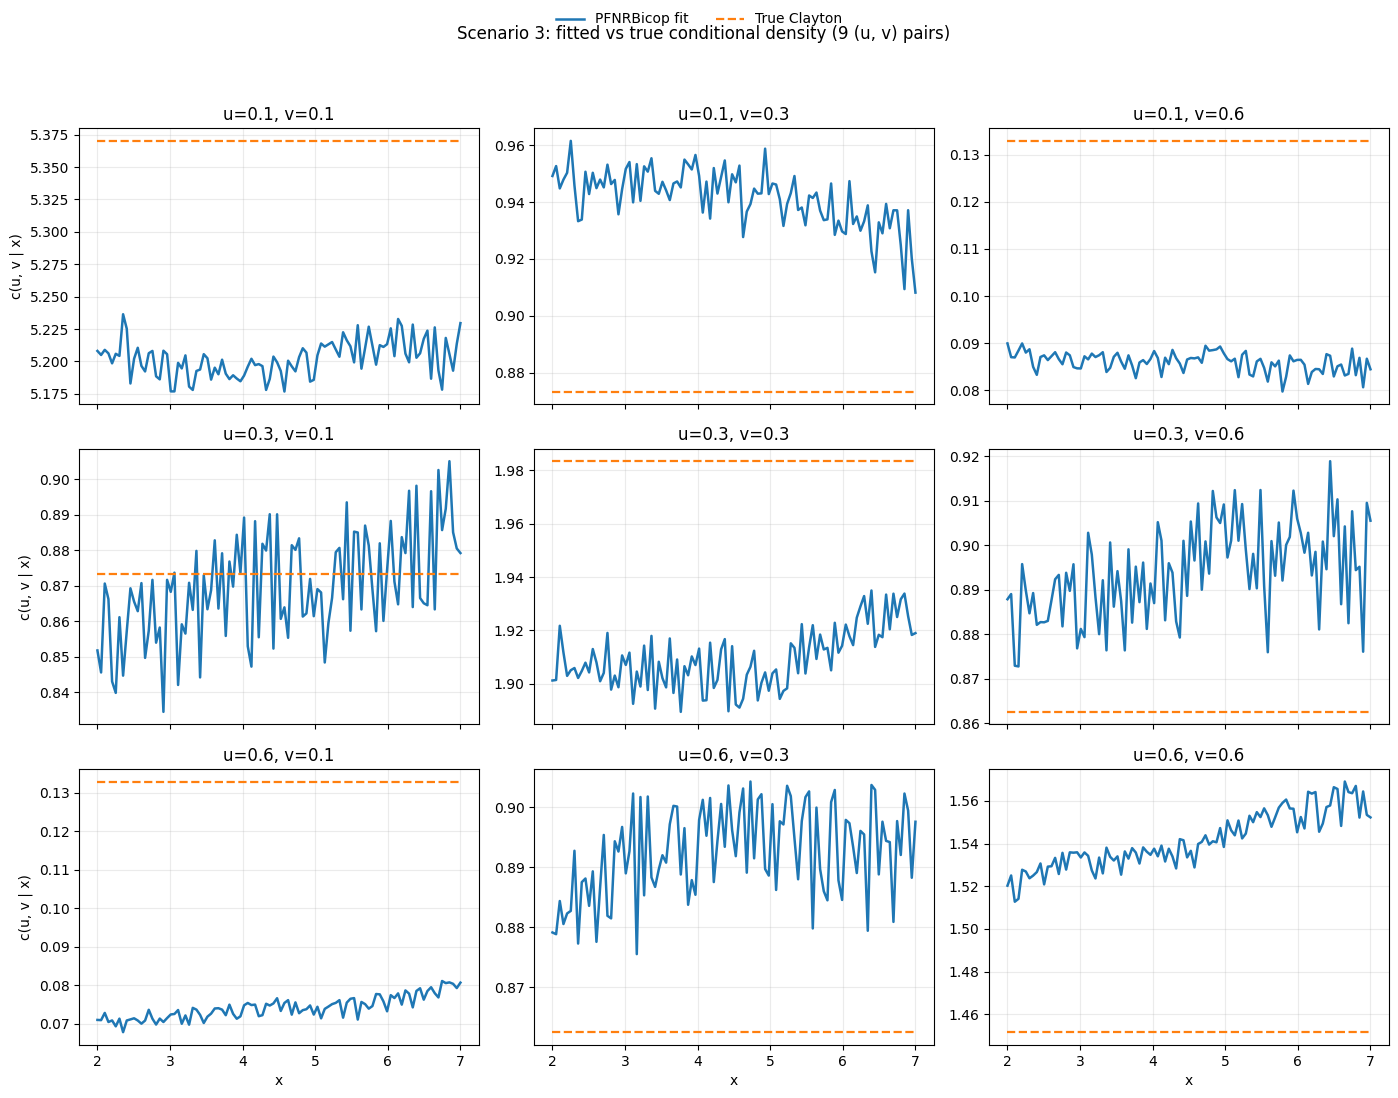

In [39]:
x_eval3 = np.linspace(df3["x"].min(), df3["x"].max(), 100)
theta3 = np.full_like(x_eval3, 2.0)

fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    c_eval3 = pfnr3.pdf(
        np.full_like(x_eval3, u0, dtype=np.float64),
        np.full_like(x_eval3, v0, dtype=np.float64),
        x=x_eval3.reshape(-1, 1),
    )

    uv_term = (u0 * v0) ** (-theta3 - 1.0)
    sum_term = (u0 ** (-theta3) + v0 ** (-theta3) - 1.0) ** (-2.0 - 1.0 / theta3)
    c_true3 = (theta3 + 1.0) * uv_term * sum_term

    ax.plot(x_eval3, c_eval3, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval3, c_true3, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("c(u, v | x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 3: fitted vs true conditional density (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Conditional CDF comparison (3x3 grid)

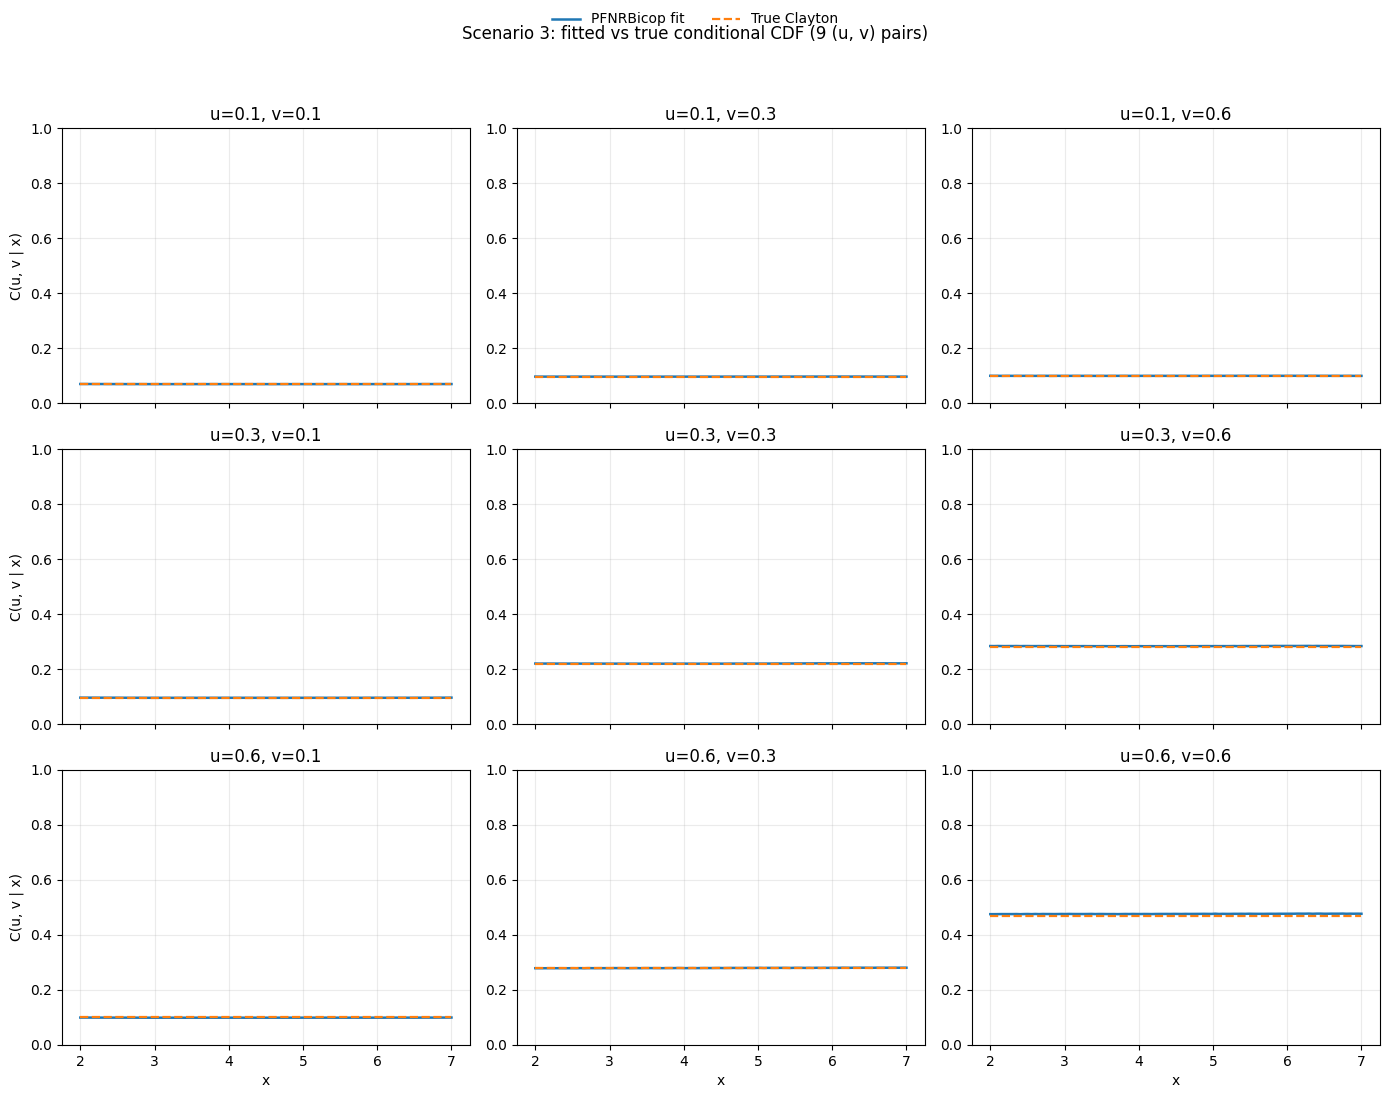

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    cdf_eval3 = pfnr3.cdf(
        np.full_like(x_eval3, u0, dtype=np.float64),
        np.full_like(x_eval3, v0, dtype=np.float64),
        x=x_eval3.reshape(-1, 1),
    )

    cdf_true3 = (u0 ** (-theta3) + v0 ** (-theta3) - 1.0) ** (-1.0 / theta3)

    ax.plot(x_eval3, cdf_eval3, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval3, cdf_true3, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("C(u, v | x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 3: fitted vs true conditional CDF (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## H-function 1 comparison (3x3 grid)

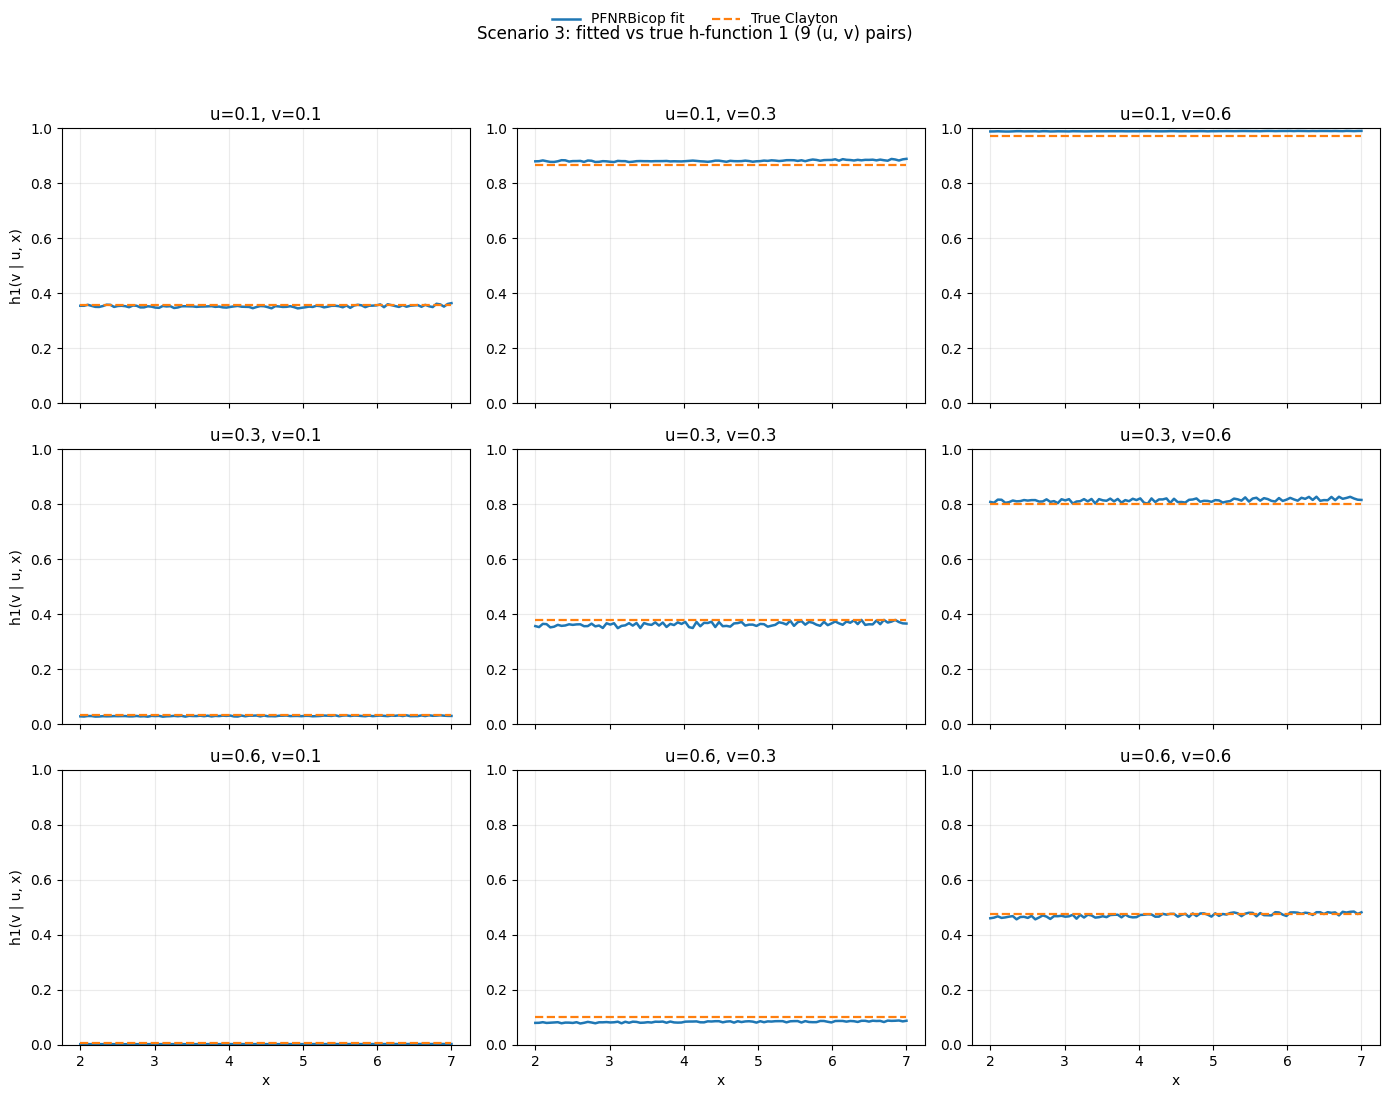

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    h1_eval3 = pfnr3.hfunc1(
        np.full_like(x_eval3, u0, dtype=np.float64),
        np.full_like(x_eval3, v0, dtype=np.float64),
        x=x_eval3.reshape(-1, 1),
    )

    h1_true3 = (u0 ** (-theta3 - 1.0)) * (u0 ** (-theta3) + v0 ** (-theta3) - 1.0) ** (-1.0 / theta3 - 1.0)

    ax.plot(x_eval3, h1_eval3, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval3, h1_true3, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("h1(v | u, x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 3: fitted vs true h-function 1 (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## H-function 2 comparison (3x3 grid)

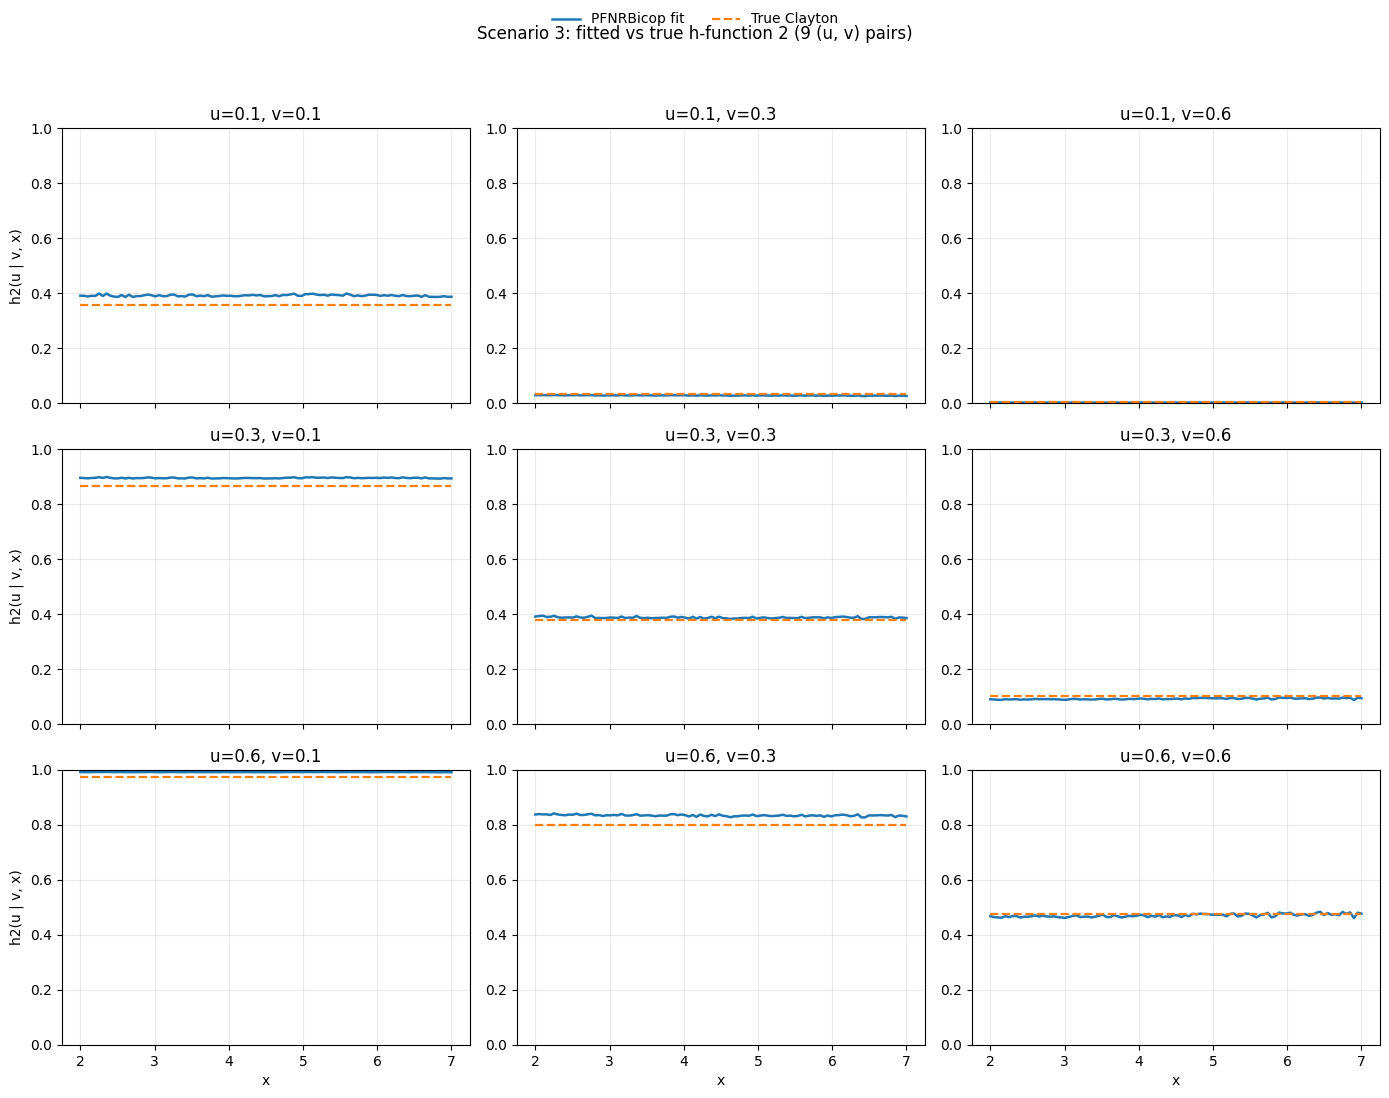

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)

for ax, (u0, v0) in zip(axes.ravel(), uv_pairs):
    h2_eval3 = pfnr3.hfunc2(
        np.full_like(x_eval3, u0, dtype=np.float64),
        np.full_like(x_eval3, v0, dtype=np.float64),
        x=x_eval3.reshape(-1, 1),
    )

    h2_true3 = (v0 ** (-theta3 - 1.0)) * (u0 ** (-theta3) + v0 ** (-theta3) - 1.0) ** (-1.0 / theta3 - 1.0)

    ax.plot(x_eval3, h2_eval3, label="PFNRBicop fit", linewidth=1.8)
    ax.plot(x_eval3, h2_true3, "--", label="True Clayton", linewidth=1.6)
    ax.set_title(f"u={u0}, v={v0}")
    ax.grid(alpha=0.25)
    ax.set_ylim(0, 1)

for ax in axes[2, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("h2(u | v, x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Scenario 3: fitted vs true h-function 2 (9 (u, v) pairs)", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Kendall's $\tau$ comparison

We compare PFNRBicop's estimated conditional Kendall's $\tau$ to the constant Clayton truth
$\tau = \theta/(\theta+2) = 0.5$ at 8 values of $x$, and to the empirical Kendall's $\tau$ from the binned data.

In [37]:
n_bins = 8
df3_bins = df3.copy()
df3_bins["x_bin"] = pd.cut(df3_bins["x"], bins=n_bins)

rows = []
for interval, g in df3_bins.groupby("x_bin", observed=True):
    x_mid = 0.5 * (interval.left + interval.right)
    tau_emp = g["u"].corr(g["v"], method="kendall")
    tau_theory = 2.0 / (2.0 + 2.0)
    rows.append((x_mid, tau_emp, tau_theory, len(g)))

tau_df3 = pd.DataFrame(rows, columns=["x_mid", "tau_emp", "tau_theory", "n"]).sort_values("x_mid")

x_tau3 = tau_df3["x_mid"].to_numpy()

tau_pfnr3 = []
for x_val in x_tau3:
    tau_pfnr3.append(pfnr3.tau(x_row=np.array([[x_val]], dtype=np.float64), n=1000))

tau_pfnr3 = np.asarray(tau_pfnr3, dtype=np.float64)
tau_true3 = tau_df3["tau_theory"].to_numpy()

tau_cmp3 = pd.DataFrame(
    {
        "x": x_tau3,
        "tau_pfnr": tau_pfnr3,
        "tau_true": tau_true3,
        "tau_emp": tau_df3["tau_emp"].to_numpy(),
        "abs_err": np.abs(tau_pfnr3 - tau_true3),
    }
)

display(tau_cmp3)

,x,tau_pfnr,tau_true,tau_emp,abs_err
0,2.3100,0.515786,0.5,0.488835,0.015786
1,2.9375,0.514967,0.5,0.505349,0.014967
2,3.5625,0.514547,0.5,0.485044,0.014547
3,4.1875,0.513778,0.5,0.502072,0.013778
4,4.8125,0.513077,0.5,0.514667,0.013077
5,5.4375,0.512549,0.5,0.522185,0.012549
6,6.0625,0.512180,0.5,0.447582,0.012180
7,6.6875,0.510963,0.5,0.488835,0.010963


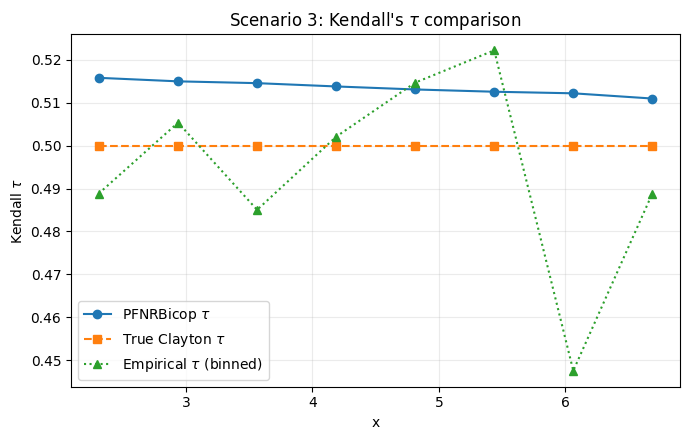

In [38]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_tau3, tau_pfnr3, marker="o", label="PFNRBicop $\\tau$")
ax.plot(x_tau3, tau_true3, marker="s", linestyle="--", label="True Clayton $\\tau$")
ax.plot(tau_df3["x_mid"], tau_df3["tau_emp"], marker="^", linestyle=":", label="Empirical $\\tau$ (binned)")
ax.set_xlabel("x")
ax.set_ylabel("Kendall $\\tau$")
ax.set_title("Scenario 3: Kendall's $\\tau$ comparison")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()